------------------
```markdown
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amendments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com
```
------------------------------
❗❗❗ **IMPORTANT**❗❗❗ **Create a copy of this notebook**

In order to work with this Google Colab you need to create a copy of it. Please **DO NOT** provide your answers here. Instead, work on the copy version. To make a copy:

**Click on: File -> save a copy in drive**

Have you successfully created the copy? if yes, there must be a new tab opened in your browser. Now move to the copy and start from there!

----------------------------------------------

# Model Assessment & Sensitivity Analysis

## Learning Objectives

By the end of this notebook, you will be able to:
1. Perform **global sensitivity analysis** using parameter variation and tornado diagrams
2. Conduct **local sensitivity analysis** with marginal effects and prior hyperparameter perturbation
3. Evaluate **robustness** to the likelihood family, prior specification, and influential observations
4. Apply and interpret all three frameworks on a concrete, real-world educational dataset

---

## Context: The Student Performance Dataset

We use a version of the **UCI Student Performance** dataset (Cortez & Silva, 2008), which records secondary-school student exam scores in mathematics along with study-related predictors.  
Our Bayesian model is:

$$\text{score}_i = \alpha + \beta_1\,\text{study\_hours}_i + \beta_2\,\text{absences}_i + \beta_3\,\text{prev\_grade}_i + \varepsilon_i$$

We treat this model as our *running example* throughout all three analysis sections.  
The three core questions we answer are:

| Section | Question |
|---|---|
| **Global sensitivity** | Which predictors drive *most* of the variance in predicted scores? |
| **Local sensitivity** | By how much does a 1-unit change in each predictor shift the score *near the mean*? |
| **Robustness** | Do our conclusions hold when we change the prior, the likelihood, or remove influential students? |

## 1. Setup and Data

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from scipy import stats
import pymc as pm
import arviz as az

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10
print('Libraries loaded successfully!')

Libraries loaded successfully!


### Construct the Dataset

We simulate a dataset that mirrors the structure and typical statistics of the UCI Student Performance data.  
Variables:
- `study_hours` — weekly study hours (1–10)
- `absences` — number of school absences (0–20)
- `prev_grade` — previous year's grade on a 0–20 scale
- `score` — current exam score on a 0–20 scale (response)

Two students are injected as **influential outliers** to stress-test robustness.

In [35]:
np.random.seed(42)
n = 120

# Predictors (realistic UCI-like ranges)
study_hours = np.random.uniform(1, 10, n)
absences    = np.random.randint(0, 20, n).astype(float)
prev_grade  = np.random.uniform(5, 18, n)

# True coefficients
true_alpha  =  2.0
true_b_sh   =  0.6   # study hours effect
true_b_abs  = -0.15  # absences effect
true_b_pg   =  0.5   # previous grade effect
true_sigma  =  1.8

score = (true_alpha
         + true_b_sh  * study_hours
         + true_b_abs * absences
         + true_b_pg  * prev_grade
         + np.random.normal(0, true_sigma, n))
score = np.clip(score, 0, 20)

# Inject two influential outliers
outlier_idx = [15, 88]
score[outlier_idx[0]] += 7.0   # student 15: scored far above model
score[outlier_idx[1]] -= 6.5   # student 88: scored far below model
score = np.clip(score, 0, 20)

df = pd.DataFrame({
    'study_hours': study_hours,
    'absences':    absences,
    'prev_grade':  prev_grade,
    'score':       score
})

print(df.describe().round(2))
print(f'\nOutlier students at indices: {outlier_idx}')

       study_hours  absences  prev_grade   score
count       120.00    120.00      120.00  120.00
mean          5.29      9.00       11.05    9.40
std           2.68      6.61        3.74    3.46
min           1.05      0.00        5.07    1.93
25%           2.78      3.00        8.22    7.18
50%           5.35      8.00       10.64    9.70
75%           7.81     15.25       13.99   11.64
max           9.88     19.00       17.93   19.04

Outlier students at indices: [15, 88]


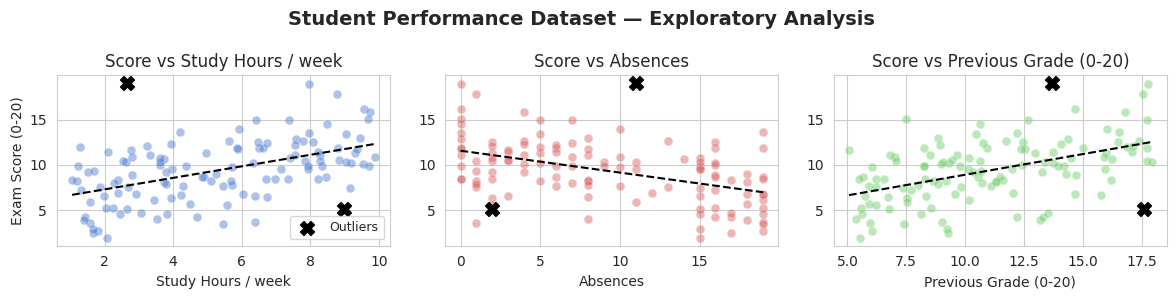

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
predictors = ['study_hours', 'absences', 'prev_grade']
labels     = ['Study Hours / week', 'Absences', 'Previous Grade (0-20)']
colors     = ['#4878CF', '#D65F5F', '#6ACC65']

for ax, pred, lab, col in zip(axes, predictors, labels, colors):
    ax.scatter(df[pred], df['score'], alpha=0.45, s=40,
               color=col, edgecolors='white', linewidth=0.4)
    ax.scatter(df[pred].iloc[outlier_idx], df['score'].iloc[outlier_idx],
               color='black', s=100, marker='X', zorder=5, label='Outliers')
    m, b = np.polyfit(df[pred], df['score'], 1)
    xs = np.linspace(df[pred].min(), df[pred].max(), 100)
    ax.plot(xs, m*xs + b, 'k--', linewidth=1.5)
    ax.set_xlabel(lab)
    ax.set_ylabel('Exam Score (0-20)' if pred == 'study_hours' else '')
    ax.set_title(f'Score vs {lab}')
    if pred == 'study_hours':
        ax.legend(fontsize=9)

fig.suptitle('Student Performance Dataset — Exploratory Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Bayesian Linear Model

Let us now construct a simpe Bayesian linear model for the data generated above.

In [37]:
# Covariate means (the 'typical student')
sh_mean = df['study_hours'].mean()
ab_mean = df['absences'].mean()
pg_mean = df['prev_grade'].mean()

# ── Fit baseline model first (needed for posterior means) ────────────
X_sh = (study_hours - study_hours.mean()) / study_hours.std()
X_ab = (absences    - absences.mean())    / absences.std()
X_pg = (prev_grade  - prev_grade.mean())  / prev_grade.std()

with pm.Model() as baseline_model:
    alpha   = pm.Normal('alpha',       mu=0, sigma=2)
    b_study = pm.Normal('b_study',     mu=0,  sigma=2)
    b_abs   = pm.Normal('b_absence',   mu=0,  sigma=2)
    b_prev  = pm.Normal('b_prevgrade', mu=0,  sigma=2)
    sigma_e = pm.HalfNormal('sigma',   sigma=3)
    mu = alpha + b_study*X_sh + b_abs*X_ab + b_prev*X_pg
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma_e, observed=score)
    trace_base = pm.sample(2000, tune=1000, chains=4, cores=4, target_accept=0.95,
                           random_seed=42, return_inferencedata=True)

post = trace_base.posterior
alpha_mean = float(post['alpha'].mean())
b_sh_mean  = float(post['b_study'].mean())
b_ab_mean  = float(post['b_absence'].mean())
b_pg_mean  = float(post['b_prevgrade'].mean())

print('Posterior means (standardised scale):')
print(f'  alpha={alpha_mean:.3f}, b_study={b_sh_mean:.3f}, '
      f'b_absence={b_ab_mean:.3f}, b_prevgrade={b_pg_mean:.3f}')

Output()

Posterior means (standardised scale):
  alpha=9.293, b_study=1.353, b_absence=-1.116, b_prevgrade=1.641


In [38]:
az.summary(trace_base,
           var_names=['alpha','b_study','b_absence','b_prevgrade','sigma']).round(3)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,9.293,0.209,8.874,9.668,0.002,0.003,9998.0,5549.0,1.0
b_study,1.353,0.219,0.937,1.762,0.002,0.003,10699.0,5474.0,1.0
b_absence,-1.116,0.216,-1.501,-0.691,0.002,0.003,10196.0,5907.0,1.0
b_prevgrade,1.641,0.211,1.255,2.052,0.002,0.003,11112.0,5582.0,1.0
sigma,2.285,0.153,2.001,2.565,0.002,0.002,9218.0,6281.0,1.0


## Sensitivity Analysis

**Goal:** Quantify how predicted scores change in response to *small perturbations* of each predictor **near the posterior mean** — the typical operating point of the model.

Using the Bayesian posterior already fitted above, we compute:

| Quantity | Formula | Interpretation |
|---|------|---|
| Marginal effect | $\partial y / \partial x_j$ = $s_j$ | 1-unit increase in $x_j$ → $s_j$ change in score |
| Elasticity | $\omega_j$ = $\frac{\log y}{\log x_j}$ | 1% increase in $x_j$ → $\omega_j$% change in score |

We then perform **prior hyperparameter perturbation**: vary the prior mean $m$ and variance $\sigma^2$, refit the model each time, and compare the resulting posteriors.

### Prior Hyperparameter Perturbation

We now perturb the prior *parameters* (not the prior family) around the baseline and check whether the posterior for $\beta_{\text{study}}$ — the most policy-relevant coefficient — changes.  

We follow the following procedure:
- **Baseline**: $\beta \sim \mathcal{N}(0,\, 2)$
- **Shifted -**: $\beta \sim \mathcal{N}(-3,\, 2)$ (double variance)
- **Shifted +**: $\beta \sim \mathcal{N}(3,\, 2)$ (half variance)

If posteriors cluster together → **locally robust**. If they spread → prior is influential.

In [39]:

prior_configs = [
    ('Baseline N(0, 2²)',      0,  2),
    ('Wider N(-3, 2²)',         -3,  2),
    ('Narrower N(3, 2²)',      3,  2),
]

posterior_study = {}

for label, prior_mu, prior_sigma in prior_configs:
    with pm.Model():
        alpha    = pm.Normal('alpha',       mu=0, sigma=3)
        b_study  = pm.Normal('b_study',     mu=prior_mu, sigma=prior_sigma)
        b_abs    = pm.Normal('b_absence',   mu=0,  sigma=2)
        b_prev   = pm.Normal('b_prevgrade', mu=0,  sigma=2)
        sigma_e  = pm.HalfNormal('sigma',   sigma=3)
        mu = alpha + b_study*X_sh + b_abs*X_ab + b_prev*X_pg
        pm.Normal('y_obs', mu=mu, sigma=sigma_e, observed=score)
        t = pm.sample(1500, tune=800, chains=4, cores=4, target_accept=0.95,
                      random_seed=42, return_inferencedata=True)
    posterior_study[label] = t.posterior['b_study'].values.flatten()

print('Posterior summary for b_study across prior configurations:')
print('='*70)
print(f'{"Configuration":<25} {"Mean":>8} {"SD":>8} {"2.5%":>8} {"97.5%":>8}')
print('-'*70)
for label, samples in posterior_study.items():
    lo, hi = np.percentile(samples, [2.5, 97.5])
    print(f'{label:<25} {samples.mean():>8.3f} {samples.std():>8.3f} {lo:>8.3f} {hi:>8.3f}')
print('='*70)

Output()

Output()

Output()

Posterior summary for b_study across prior configurations:
Configuration                 Mean       SD     2.5%    97.5%
----------------------------------------------------------------------
Baseline N(0, 2²)            1.346    0.216    0.932    1.775
Wider N(-3, 2²)              1.313    0.221    0.889    1.746
Narrower N(3, 2²)            1.385    0.219    0.949    1.806


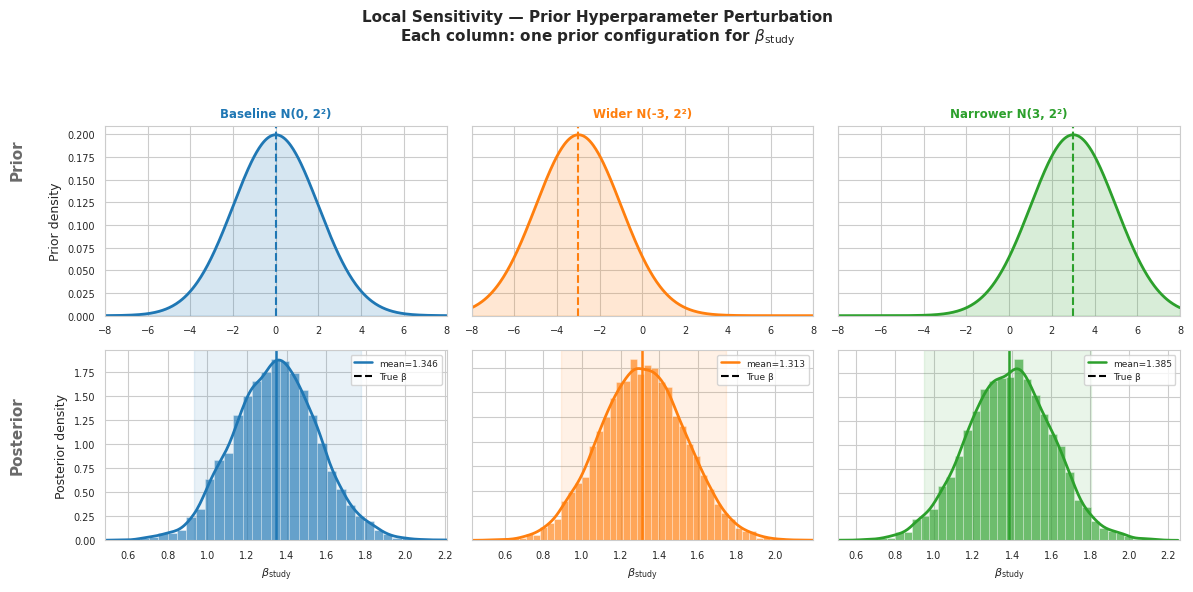

Conclusion:
If posteriors (bottom row) cluster tightly → data dominate; locally robust.
If the bottom-row peaks shift with the top-row mean → prior is informative.


In [40]:
palette = ['#1f77b4','#ff7f0e','#2ca02c']
labels_list = list(posterior_study.keys())
n_configs = len(prior_configs)
x_prior = np.linspace(-8, 8, 400)
true_b_std = true_b_sh / study_hours.std()

fig, axes = plt.subplots(2, n_configs, figsize=(12, 6),
                         sharex=False)

for col_idx, ((label, prior_mu, prior_sigma), col) in enumerate(
        zip(prior_configs, palette)):

    # ── TOP ROW: prior distribution ──────────────────────────────────
    ax_top = axes[0, col_idx]
    prior_pdf = stats.norm.pdf(x_prior, loc=prior_mu, scale=prior_sigma)
    ax_top.plot(x_prior, prior_pdf, color=col, linewidth=2)
    ax_top.fill_between(x_prior, prior_pdf, alpha=0.18, color=col)
    ax_top.axvline(prior_mu, color=col, linestyle='--', linewidth=1.5,
                   label=f'mean={prior_mu}')
    ax_top.set_title(label, fontsize=8.5, fontweight='bold', color=col)
    ax_top.set_xlim(-8, 8)
    ax_top.set_ylim(bottom=0)
    ax_top.tick_params(labelsize=7)
    if col_idx == 0:
        ax_top.set_ylabel('Prior density', fontsize=9)
    else:
        ax_top.set_ylabel('')
        ax_top.set_yticklabels([])

    # ── BOTTOM ROW: resulting posterior ──────────────────────────────
    ax_bot = axes[1, col_idx]
    samples = posterior_study[label]
    ax_bot.hist(samples, bins=45, alpha=0.65, density=True,
                color=col, edgecolor='white', linewidth=0.4)
    # KDE overlay
    xkde = np.linspace(samples.min() - 0.1, samples.max() + 0.1, 300)
    kde  = stats.gaussian_kde(samples)
    ax_bot.plot(xkde, kde(xkde), color=col, linewidth=2)
    ax_bot.axvline(samples.mean(), color=col, linestyle='-',
                   linewidth=1.8, label=f'mean={samples.mean():.3f}')
    ax_bot.axvline(true_b_std, color='black', linestyle='--',
                   linewidth=1.5, label='True β')
    lo, hi = np.percentile(samples, [2.5, 97.5])
    ax_bot.axvspan(lo, hi, alpha=0.10, color=col)
    ax_bot.set_xlim(samples.mean() - 4*samples.std(),
                    samples.mean() + 4*samples.std())
    ax_bot.set_ylim(bottom=0)
    ax_bot.set_xlabel(r'$\beta_{\mathrm{study}}$', fontsize=8)
    ax_bot.tick_params(labelsize=7)
    ax_bot.legend(fontsize=6.5, loc='upper right')
    if col_idx == 0:
        ax_bot.set_ylabel('Posterior density', fontsize=9)
    else:
        ax_bot.set_yticklabels([])

# Row labels
fig.text(0.01, 0.73, 'Prior', va='center', rotation='vertical',
         fontsize=11, fontweight='bold', color='dimgray')
fig.text(0.01, 0.27, 'Posterior', va='center', rotation='vertical',
         fontsize=11, fontweight='bold', color='dimgray')

fig.suptitle('Local Sensitivity — Prior Hyperparameter Perturbation\n'
             r'Each column: one prior configuration for $\beta_{\mathrm{study}}$',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0.03, 0, 1, 0.93])
plt.show()

print('Conclusion:')
print('If posteriors (bottom row) cluster tightly → data dominate; locally robust.')
print('If the bottom-row peaks shift with the top-row mean → prior is informative.')

### Exercise

Repeat the above analysis for the variance of $\beta$_study.

In [41]:
# Your code here

### Exercise
Perform alasticity analysis for $\beta$_study.

In [42]:
# Your code here

## Robustness

Robustness asks: *do our substantive conclusions survive reasonable changes in **model form**?*  
We run three complementary checks:

| Test | What changes | What we compare |
|---|---|---|
| **Likelihood family** | Normal → Student-$t$ | Posterior of $\beta_{\text{study}}$; fitted lines |
| **Data subset** | Remove influential outliers | Posterior shift after exclusion |
| **Prior family** | Widen/narrow prior *scales* | Range of 95% HPD across 4 configurations |

### Likelihood Robustness: Normal vs Student-$t$

The Normal likelihood is sensitive to outliers. A Student-$t$ likelihood with small degrees of freedom $\nu$ has heavier tails that **downweight outlier students automatically**.  

We estimate $\nu$ from data via a $\text{Gamma}(2, 0.1)$ prior (mean $\approx 20$, but data can push it toward 3–5 if outliers are present).

In [43]:
# ── Model 1: Normal likelihood (baseline) — already fitted above ────────
# We reuse trace_base

# ── Model 2: Student-t likelihood ────────────────────────────────────────
with pm.Model() as robust_model:
    alpha   = pm.Normal('alpha',       mu=0, sigma=3)
    b_study = pm.Normal('b_study',     mu=0,  sigma=2)
    b_abs   = pm.Normal('b_absence',   mu=0,  sigma=2)
    b_prev  = pm.Normal('b_prevgrade', mu=0,  sigma=2)
    sigma_e = pm.HalfNormal('sigma',   sigma=3)
    nu      = pm.Gamma('nu', alpha=2, beta=0.1)  # degrees of freedom

    mu = alpha + b_study*X_sh + b_abs*X_ab + b_prev*X_pg
    pm.StudentT('y_obs', nu=nu, mu=mu, sigma=sigma_e, observed=score)

    trace_robust = pm.sample(2000, tune=1000, chains=4, cores=4,
                             target_accept=0.95, random_seed=42, return_inferencedata=True)

nu_post = trace_robust.posterior['nu'].values.flatten()
print(f'Posterior ν: mean={nu_post.mean():.1f}, median={np.median(nu_post):.1f}, '
      f'90% CI=[{np.percentile(nu_post,5):.1f}, {np.percentile(nu_post,95):.1f}]')
print('Low ν → heavy tails → outlier student scores are downweighted.')

Output()

Posterior ν: mean=6.7, median=5.8, 90% CI=[3.1, 13.0]
Low ν → heavy tails → outlier student scores are downweighted.


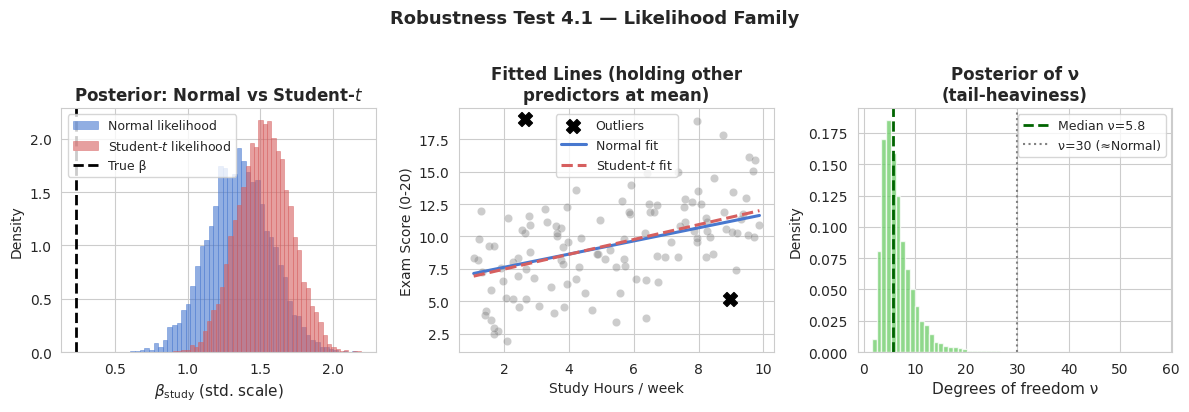

Normal likelihood:    β_study = 1.353 ± 0.219
Student-t likelihood: β_study = 1.527 ± 0.184
True β (std. scale)           = 0.225


In [44]:
b_normal = trace_base.posterior['b_study'].values.flatten()
b_robust = trace_robust.posterior['b_study'].values.flatten()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# ── (a) Posterior comparison ───────────────────────────────────────────
axes[0].hist(b_normal, bins=50, alpha=0.6, density=True,
             color='#4878CF', edgecolor='#4878CF', linewidth=0.5, label='Normal likelihood')
axes[0].hist(b_robust, bins=50, alpha=0.6, density=True,
             color='#D65F5F', edgecolor='#D65F5F', linewidth=0.5, label='Student-$t$ likelihood')
axes[0].axvline(true_b_sh / study_hours.std(), color='black',
                linestyle='--', linewidth=2, label='True β')
axes[0].set_xlabel(r'$\beta_{\mathrm{study}}$ (std. scale)', fontsize=11)
axes[0].set_ylabel('Density')
axes[0].set_title('Posterior: Normal vs Student-$t$', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# ── (b) Fitted lines on data ───────────────────────────────────────────
a_n = float(trace_base.posterior['alpha'].mean())
b_n = float(b_normal.mean())
a_r = float(trace_robust.posterior['alpha'].mean())
b_r = float(b_robust.mean())

xs_std = np.linspace(X_sh.min(), X_sh.max(), 200)
sh_orig= xs_std * study_hours.std() + study_hours.mean()

axes[1].scatter(study_hours, score, alpha=0.4, s=35, color='gray',
                edgecolors='white', linewidth=0.3)
axes[1].scatter(study_hours[outlier_idx], score[outlier_idx],
                color='black', s=100, marker='X', zorder=6, label='Outliers')
axes[1].plot(sh_orig, a_n + b_n*xs_std, color='#4878CF', linewidth=2.2, label='Normal fit')
axes[1].plot(sh_orig, a_r + b_r*xs_std, color='#D65F5F', linewidth=2.2,
             linestyle='--', label='Student-$t$ fit')
axes[1].set_xlabel('Study Hours / week')
axes[1].set_ylabel('Exam Score (0-20)')
axes[1].set_title('Fitted Lines (holding other\npredictors at mean)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

# ── (c) Posterior of ν ────────────────────────────────────────────────
axes[2].hist(nu_post, bins=60, color='#6ACC65', alpha=0.75, density=True, edgecolor='white')
axes[2].axvline(np.median(nu_post), color='darkgreen', linewidth=2,
                linestyle='--', label=f'Median ν={np.median(nu_post):.1f}')
axes[2].axvline(30, color='gray', linewidth=1.5, linestyle=':',
                label='ν=30 (≈Normal)')
axes[2].set_xlabel('Degrees of freedom ν', fontsize=11)
axes[2].set_ylabel('Density')
axes[2].set_title('Posterior of ν\n(tail-heaviness)', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Robustness Test 4.1 — Likelihood Family',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Normal likelihood:    β_study = {b_normal.mean():.3f} ± {b_normal.std():.3f}')
print(f'Student-t likelihood: β_study = {b_robust.mean():.3f} ± {b_robust.std():.3f}')
print(f'True β (std. scale)           = {true_b_sh/study_hours.std():.3f}')

### Data-Subset Robustness: Removing Influential Observations

We refit the Normal model after **excluding the two outlier students** and compare the resulting posteriors to the full-data results.

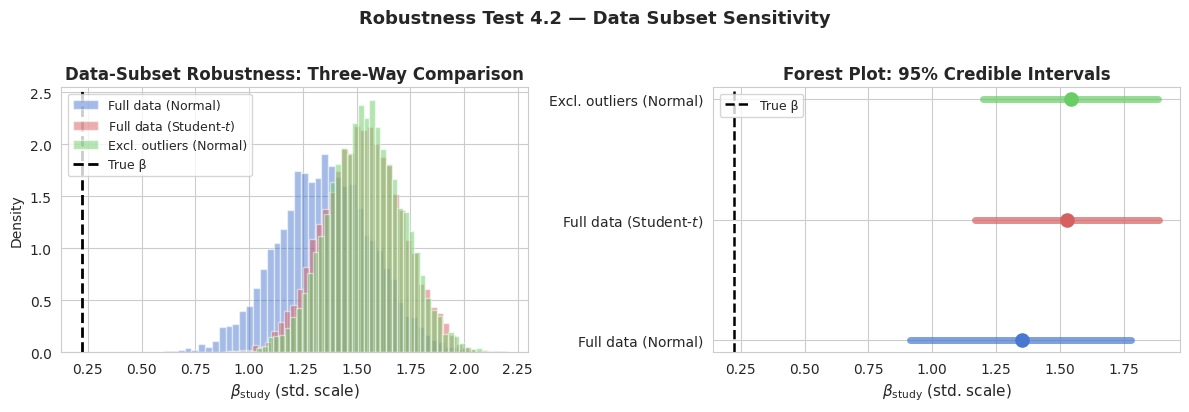

Summary:
Full data (Normal)             mean=+1.353  95%CI=[+0.914, +1.781]
Full data (Student-$t$)        mean=+1.527  95%CI=[+1.166, +1.888]
Excl. outliers (Normal)        mean=+1.542  95%CI=[+1.201, +1.885]
True β (std. scale) = +0.225


In [45]:
mask = np.ones(n, dtype=bool)
mask[outlier_idx] = False

X_sh_c  = X_sh[mask];   X_ab_c = X_ab[mask];   X_pg_c = X_pg[mask]
score_c = score[mask]

with pm.Model() as clean_model:
    alpha   = pm.Normal('alpha',       mu=10, sigma=3)
    b_study = pm.Normal('b_study',     mu=0,  sigma=2)
    b_abs   = pm.Normal('b_absence',   mu=0,  sigma=2)
    b_prev  = pm.Normal('b_prevgrade', mu=0,  sigma=2)
    sigma_e = pm.HalfNormal('sigma',   sigma=3)
    mu = alpha + b_study*X_sh_c + b_abs*X_ab_c + b_prev*X_pg_c
    pm.Normal('y_obs', mu=mu, sigma=sigma_e, observed=score_c)
    trace_clean = pm.sample(2000, tune=1000, chains=4, cores=4,
                            target_accept=0.95, random_seed=42, return_inferencedata=True, progressbar=False)

b_clean = trace_clean.posterior['b_study'].values.flatten()

# ── Three-way comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels3  = ['Full data (Normal)', 'Full data (Student-$t$)', 'Excl. outliers (Normal)']
samples3 = [b_normal, b_robust, b_clean]
cols3    = ['#4878CF', '#D65F5F', '#6ACC65']

for label, samp, col in zip(labels3, samples3, cols3):
    axes[0].hist(samp, bins=50, alpha=0.5, density=True, color=col, label=label)
axes[0].axvline(true_b_sh / study_hours.std(), color='black',
                linestyle='--', linewidth=2, label='True β')
axes[0].set_xlabel(r'$\beta_{\mathrm{study}}$ (std. scale)', fontsize=11)
axes[0].set_ylabel('Density')
axes[0].set_title('Data-Subset Robustness: Three-Way Comparison', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# Forest plot
ypos = np.arange(3)
for i, (samp, col) in enumerate(zip(samples3, cols3)):
    lo, hi = np.percentile(samp, [2.5, 97.5])
    axes[1].plot([lo, hi], [i, i], color=col, linewidth=5, alpha=0.7)
    axes[1].scatter([samp.mean()], [i], color=col, s=90, zorder=5)
axes[1].axvline(true_b_sh / study_hours.std(), color='black',
                linestyle='--', linewidth=1.8, label='True β')
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(labels3, fontsize=10)
axes[1].set_xlabel(r'$\beta_{\mathrm{study}}$ (std. scale)', fontsize=11)
axes[1].set_title('Forest Plot: 95% Credible Intervals', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Robustness Test 4.2 — Data Subset Sensitivity',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Summary:')
print('='*65)
for label, samp in zip(labels3, samples3):
    lo, hi = np.percentile(samp, [2.5, 97.5])
    print(f'{label:<30} mean={samp.mean():+.3f}  95%CI=[{lo:+.3f}, {hi:+.3f}]')
print('='*65)
print(f'True β (std. scale) = {true_b_sh/study_hours.std():+.3f}')

### Prior-Family Robustness
Here, we would like to test whether conclusions change when we replace the Normal prior with alternative prior families that encode different beliefs about the plausible range and tail behaviour of the coefficients.

We will try the following families:

| Family | Prior Params |
|---|---|
| Normal | $N(0, 2^2)$ |
| Laplace | $L(0, 1)$ |
| Student | $T(0, 2)$ |
| Cauchy | $C(0, 1)$ |

In [46]:
import pytensor.tensor as pt

coef_names  = ['b_study', 'b_absence', 'b_prevgrade']
coef_labels = [r'$\beta_{\mathrm{study}}$', r'$\beta_{\mathrm{absence}}$',
               r'$\beta_{\mathrm{prevgrade}}$']
true_betas_std = [
    true_b_sh  / study_hours.std(),
    true_b_abs / absences.std(),
    true_b_pg  / prev_grade.std(),
]

prior_families = [
    ('Normal N(0,1²)',   'normal'),
    ('Laplace(0,1)',     'laplace'),
    ('Student-t₃(0,1)', 'studentt'),
    ('Cauchy(0,1)',      'cauchy'),
]

hpd_family = {c: {'lo': [], 'hi': [], 'mean': [], 'label': []}
              for c in coef_names}

for fam_label, fam_key in prior_families:
    with pm.Model():
        alpha = pm.Normal('alpha', mu=0, sigma=3)

        def make_prior(name, fam_key):
            if fam_key == 'normal':
                return pm.Normal(name, mu=0, sigma=1)
            elif fam_key == 'laplace':
                return pm.Laplace(name, mu=0, b=1)
            elif fam_key == 'studentt':
                return pm.StudentT(name, nu=3, mu=0, sigma=1)
            elif fam_key == 'cauchy':
                return pm.Cauchy(name, alpha=0, beta=1)

        b_study = make_prior('b_study',     fam_key)
        b_abs   = make_prior('b_absence',   fam_key)
        b_prev  = make_prior('b_prevgrade', fam_key)
        sigma_e = pm.HalfNormal('sigma', sigma=3)

        mu = alpha + b_study*X_sh + b_abs*X_ab + b_prev*X_pg
        pm.Normal('y_obs', mu=mu, sigma=sigma_e, observed=score)

        t = pm.sample(1500, tune=800, chains=4, cores=4, target_accept=0.9,
                      random_seed=42, return_inferencedata=True)

    for c in coef_names:
        samp = t.posterior[c].values.flatten()
        lo, hi = np.percentile(samp, [2.5, 97.5])
        hpd_family[c]['lo'].append(lo)
        hpd_family[c]['hi'].append(hi)
        hpd_family[c]['mean'].append(samp.mean())
        hpd_family[c]['label'].append(fam_label)

print('Posterior means across prior families:')
print('='*70)
print(f'{"Prior family":<22}', '  '.join(f'{lab:>18}' for lab in coef_labels))
print('-'*70)
for i, (fam_label, _) in enumerate(prior_families):
    row = '  '.join(f'{hpd_family[c]["mean"][i]:>18.4f}' for c in coef_names)
    print(f'{fam_label:<22}  {row}')
print('='*70)

Output()

Output()

Output()

Output()

Posterior means across prior families:
Prior family           $\beta_{\mathrm{study}}$  $\beta_{\mathrm{absence}}$  $\beta_{\mathrm{prevgrade}}$
----------------------------------------------------------------------
Normal N(0,1²)                      1.3149             -1.0956              1.5873
Laplace(0,1)                        1.3264             -1.0932              1.6152
Student-t₃(0,1)                     1.3210             -1.0964              1.6134
Cauchy(0,1)                         1.3213             -1.0969              1.6225


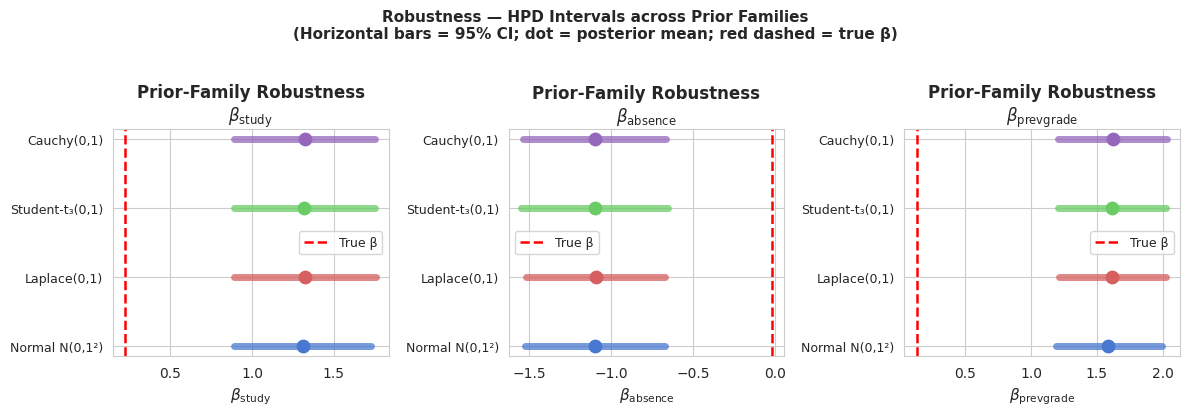


Conclusion:
CIs that overlap strongly across families → conclusions are prior-family-robust.
Diverging CIs → tail behaviour of the prior matters; justify family choice carefully.


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

family_colors = ['#4878CF', '#D65F5F', '#6ACC65', '#9467bd']

for ax, c, lab, true_b in zip(axes, coef_names, coef_labels, true_betas_std):
    for i, (fam_label, col) in enumerate(
            zip(hpd_family[c]['label'], family_colors)):
        lo = hpd_family[c]['lo'][i]
        hi = hpd_family[c]['hi'][i]
        m  = hpd_family[c]['mean'][i]
        ax.plot([lo, hi], [i, i], color=col, linewidth=5, alpha=0.75)
        ax.scatter([m], [i], color=col, s=80, zorder=5)

    ax.axvline(true_b, color='red', linestyle='--', linewidth=1.8, label='True β')
    ax.set_yticks(range(len(prior_families)))
    ax.set_yticklabels(hpd_family[c]['label'], fontsize=9)
    ax.set_xlabel(lab, fontsize=11)
    ax.set_title(f'Prior-Family Robustness\n{lab}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Robustness — HPD Intervals across Prior Families\n'
             '(Horizontal bars = 95% CI; dot = posterior mean; '
             'red dashed = true β)',
             fontsize=11, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('\nConclusion:')
print('CIs that overlap strongly across families → conclusions are prior-family-robust.')
print('Diverging CIs → tail behaviour of the prior matters; justify family choice carefully.')

### Exercise

Using the same student performance dataset, investigate whether the **absences** coefficient behaves differently from the study-hours coefficient under robustness checks.

In [48]:
# Your code here

**Congratulations! You have finished the Notebook! Great Job!** 🤗🙌👍👏💪

<!--
# Copyright © 2025 Meysam Goodarzi
This notebook is licensed under CC BY-NC 4.0 with the following amendments:
- Individuals may use, share, and adapt this material for non-commercial purposes with attribution.
- Institutions/Companies must obtain written consent to use this material, except for nonprofits.
- Commercial use is prohibited without permission.  
Contact: analytica@meysam-goodarzi.com.
-->